<a href="https://colab.research.google.com/github/MishelleMurcia26/Analitica-de-Negocios-/blob/main/Clustering_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio**
Una entidad financiera (FINTECH) quiere implementar un modelo de arbol de decision para mejorar la preaprobacion de creditos de consumo de sus solicitantes de este tipo de creditos.Para este proceso vamos a utilizar las cariables:

*Edad:Indica el numero de años que posee una persona,o el tiempo que usted lleva en el sistema financiero.
*Ingresos: Engloba todos los ingresos que recibe una persona ademas si posee salario minimo(USD)
*Egresos:
*Monto(EAD):

0. Se procede con la carga de las librerias de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Herramienta para graficas estadisticas

from sklearn.cluster import KMeans    #Herramienta de clustering

1. Se cargan los datos de trabajo

<Axes: >

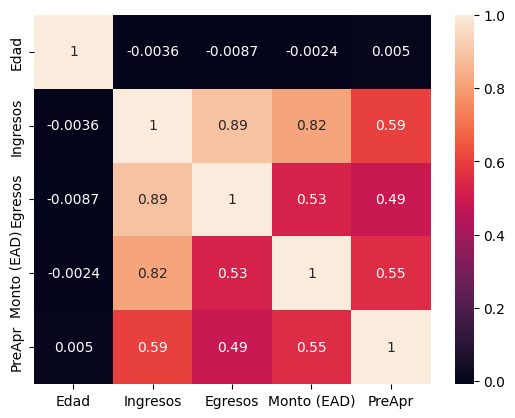

In [ ]:
nxl="/content/0. SolicitantesCrédito(USD)_MMK_Clase.xlsx"
XDB=pd.read_excel(nxl,sheet_name=1)

#Seleccionamos variables de trabajo

XD=XDB.iloc[:,[1,10,11,25]]
yd=XDB.iloc[:,32]

#Determinamos la correlacion entre las varibales
XDB2=XDB.iloc[:,[1,10,11,25,32]]
sns.heatmap(XDB2.corr(),annot=True)

2. Se procede con la implementacion del modelo KMeans

In [ ]:
from pandas.io.pytables import TableIterator
np.random.seed(42)  # Esto permite generar las mismas semillas para todos
NC=5   #CINCO SEGMENTOS O PERFILES DE CLIENTES
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd)  # el modelo busca la mejor relacion emtre la entrada y la salida

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las perdonas mkm.cluster_centers_ que encontro el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreApro o PreNeg por segmento, sucursal o perfil
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp)   #Numero de datos por segmento
print("El numero de datos por cluster es:  ", NDc)


,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


El numero de datos por cluster es:   [2127  264  485  960 2006]


3. Porcentaje de PreApro

In [ ]:
XDB2["Cluster"]=ydp
display(XDB2)

#Determinar el nuemro de preapro y preneg por cluster

NApr=XDB2.groupby("Cluster").agg({"PreApr":lambda x: (x==1).sum()})
NPrn=XDB2.groupby("Cluster").agg({"PreApr":lambda x: (x==0).sum()})
#Para que la decision sea en porcentaje
NApr2=NApr/(NApr+NPrn);NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2,NPrn2)),columns=["PreApr","PreNeg"])
display(df2)

/tmp/ipython-input-156/3397736964.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2["Cluster"]=ydp


,Edad,Ingresos,Egresos,Monto (EAD),PreApr,Cluster
0,38,1356.14400,1685.622667,625.562230,1,3
1,51,286.01600,364.462000,140.031984,1,0
2,37,517.46325,629.208889,284.564492,0,4
3,29,473.27000,551.616889,309.647588,1,4
4,42,750.09175,806.715778,500.663578,1,4
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,1,3
5838,31,1472.77200,953.812889,870.793819,1,3
5839,38,773.01975,672.910667,594.947894,1,4
5840,43,635.50175,780.691556,305.580539,1,4


,PreApr,PreNeg
0,0.137283,0.862717
1,0.962121,0.037879
2,0.973196,0.026804
3,0.772917,0.227083
4,0.559821,0.440179


4. Que pasa di aparece una nueva persona?
Edad=30. Ingresos=500, Egresos=200, Monto=150

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
Patricia=np.array([[30,500,200,150]])
ydp=mkm.predict(Patricia)  #Reshape= quitarle la estructura
NC1=ydp[0]   #Esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster: ", ydp)
print("El porcentaje de preaprobacion para patricia es :", NApr2.iloc[NC1])
print("El porcentaje de prenegacion para patricia es :", NPrn2.iloc[NC1])

La persona pertenece al cluster:  [0]
El porcentaje de preaprobacion para patricia es : PreApr    0.137283
Name: 0, dtype: float64
El porcentaje de prenegacion para patricia es : PreApr    0.862717
Name: 0, dtype: float64


5. Se procede con la grafica de los clusters utilizando las variables ingreso y egresos

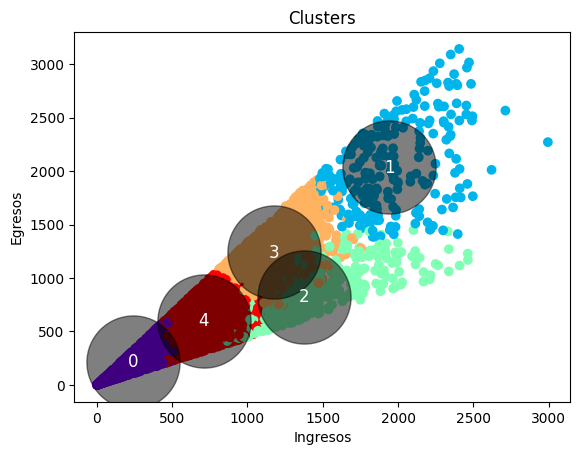

In [ ]:
centers=mkm.cluster_centers_  #Centroides, perfil; o segmento
ing=np.array(XD.iloc[:,1])
egr=np.array(XD.iloc[:,2])
plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap="rainbow")
plt.scatter(centers[:,1],centers[:,2],c="black",s=4500,alpha=0.5)
plt.xlabel("Ingresos")
plt.ylabel("Egresos")
plt.title("Clusters")

#Add numbers to the centers
for i,center in enumerate(centers):
  plt.text(center[1], center[2], str(i), color="white", fontsize=12, ha="center", va="center")
plt.show()


**Analisis de resultado**
En el heatmap se puede observar que las variables que tienen una mayor correlacion entre ellas son las variables de ingreso y egreso con 89%. Esto indica que si una variable aumenta el valor, la otra tambien se incremnta(SI gano mucho , gasto mucho ). Otra correlacion de relevancia es la correlacion entre ingresos y monto(0.82), personas con altos ingresos, piden montos mayores (bajos ingresos-montos menores). Se destaca igualmente que la varibale que tiene una mayor correlacion con la variable PreApro (Salida) es la variable ingresos(0.59).

De acuerdo con los segmentos o cluster arrojados por el modelo podemos observar que el cluster 1 y el cluster 2 son los que poseen los ingresos mas altos con 1943 y 1378 respectivamente. Cluster que igualmente son los que tiene  la menor cantidad de solicitantes de credito con 264 y 485. Se destaca el primer cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo que posee la mayor cantidad de solicitantes de credito(2127)

Se puede observar que el cluster 1 y el cluster 2 agrupan las posibilidades mas altas frente a la preaprobacion del credito con un 96% y 97% de preaprobacion respectivamente. Es importante mencionar que el cluster 0 tuvo los menores porcentaje de preaprobacion, esto promovido por los menores ingresos para las personas que hacen parte de este cluster